In [1]:
!pip install kagglehub

In [2]:

import kagglehub

path = kagglehub.dataset_download("sumn2u/garbage-classification-v2")
print("Dataset path:", path)

Using Colab cache for faster access to the 'garbage-classification-v2' dataset.
Dataset path: /kaggle/input/garbage-classification-v2


In [3]:

import os

print("Top-level folders:", os.listdir(path))

Top-level folders: ['standardized_384', 'original', 'standardized_256']


In [4]:

for root, dirs, files in os.walk(path):
    print("Root:", root)
    print("Folders:", dirs)
    break

Root: /kaggle/input/garbage-classification-v2
Folders: ['standardized_384', 'original', 'standardized_256']


In [5]:

import os

# Auto-find folder that contains class folders
data_dir = None

for root, dirs, files in os.walk(path):
    if any(cls in dirs for cls in ["cardboard", "glass", "metal", "paper", "plastic", "trash"]):
        data_dir = root
        break

print("Using dataset directory:", data_dir)

Using dataset directory: /kaggle/input/garbage-classification-v2/standardized_384


In [6]:

import tensorflow as tf

img_size = (128, 128)
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

Found 12259 files belonging to 10 classes.
Using 9808 files for training.
Found 12259 files belonging to 10 classes.
Using 2451 files for validation.


In [7]:

class_names = train_ds.class_names
print("Classes:", class_names)

Classes: ['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']


In [8]:

normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

In [9]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

num_classes = len(class_names)

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 204s 659ms/step - accuracy: 0.3420 - loss: 1.8783 - val_accuracy: 0.4529 - val_loss: 1.5663
Epoch 2/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 190s 619ms/step - accuracy: 0.4923 - loss: 1.4802 - val_accuracy: 0.5745 - val_loss: 1.2647
Epoch 3/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 190s 619ms/step - accuracy: 0.5549 - loss: 1.3036 - val_accuracy: 0.5871 - val_loss: 1.2489
Epoch 4/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 203s 620ms/step - accuracy: 0.6058 - loss: 1.1566 - val_accuracy: 0.6144 - val_loss: 1.1825
Epoch 5/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 194s 630ms/step - accuracy: 0.6483 - loss: 1.0255 - val_accuracy: 0.6499 - val_loss: 1.0873
Epoch 6/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 200s 652ms/step - accuracy: 0.6891 - loss: 0.9131 - val_accuracy: 0.6716 - val_loss: 1.0516
Epoch 7/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 194s 633ms/step - accuracy: 0.7237 - loss: 0.8118 - val_accuracy: 0.6528 - val_loss: 1.1539
Epoch 8/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 208s 653ms/step - accuracy: 0.7541 -

In [12]:

loss, acc = model.evaluate(val_ds)
print("Validation Accuracy:", acc)

77/77 ━━━━━━━━━━━━━━━━━━━━ 14s 183ms/step - accuracy: 0.6736 - loss: 1.1257
Validation Accuracy: 0.6736026406288147


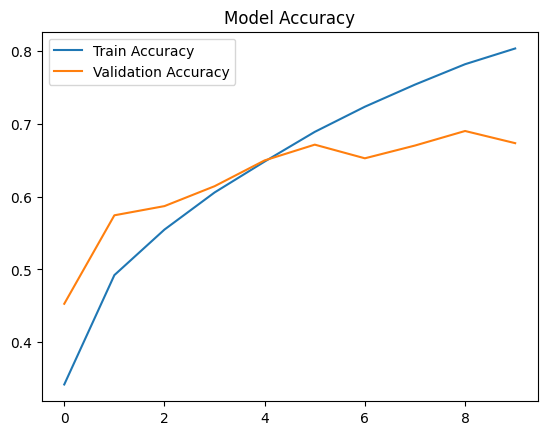

In [13]:

import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.legend()
plt.title("Model Accuracy")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 590ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

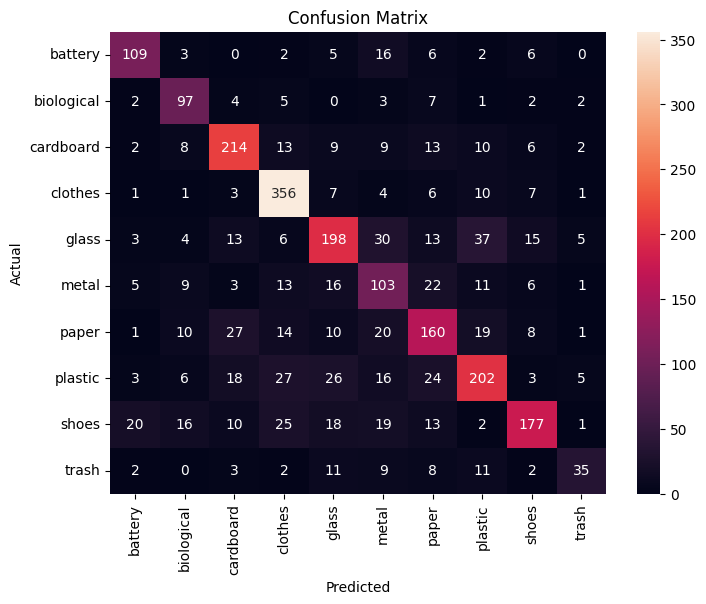

In [14]:

import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names))

import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [15]:
import os

print(os.listdir())

['.config', 'sample_data']


In [18]:
model.save("waste_cnn_model.keras")

In [29]:
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader

train_tf = transforms.Compose([
    transforms.Resize((224, 224)),   # IMPORTANT for real dataset
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor()
])

test_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

import os

dataset_path = path  # from kagglehub

dataset = torchvision.datasets.ImageFolder(
    root=dataset_path,
    transform=train_tf
)

In [30]:
train_loader = DataLoader(dataset, batch_size=64, shuffle=True)

In [39]:
import os

print(os.listdir(path))

['standardized_384', 'original', 'standardized_256']


In [41]:
dataset_path = os.path.join(path, "original")

In [42]:
from torchvision import datasets
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(root=dataset_path, transform=transform)

train_loader = DataLoader(dataset, batch_size=32, shuffle=True)

classes = dataset.classes
print("Classes:", classes)

Classes: ['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']


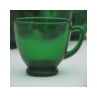

Class: glass


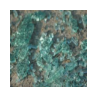

Class: glass


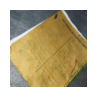

Class: paper


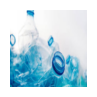

Class: plastic


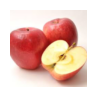

Class: biological


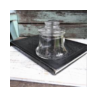

Class: glass


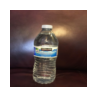

Class: plastic


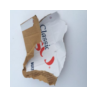

Class: cardboard


In [43]:
import matplotlib.pyplot as plt

def imshow(img):
    img = img.numpy().transpose((1, 2, 0))
    plt.figure(figsize=(1, 1))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

dataiter = iter(train_loader)
images, labels = next(dataiter)

for i in range(8):
    imshow(images[i])
    print("Class:", classes[labels[i].item()])

In [44]:
model.save("waste_cnn_model.h5")

In [45]:
import tensorflow as tf

model = tf.keras.models.load_model("waste_cnn_model.h5")

In [140]:
from google.colab import files

uploaded = files.upload()

Saving cardboard.jpg to cardboard.jpg


In [141]:
img_path = list(uploaded.keys())[0]
print("Using image:", img_path)

Using image: cardboard.jpg


In [142]:
import numpy as np
from tensorflow.keras.preprocessing import image

img = image.load_img(img_path, target_size=(128, 128))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

In [143]:
pred = model.predict(img_array)

class_names = ['battery', 'biological', 'cardboard', 'clothes', 'glass',
                'metal', 'paper', 'plastic', 'shoes', 'trash']

pred_class = class_names[np.argmax(pred)]
confidence = np.max(pred) * 100

print("Predicted Class:", pred_class)
print("Confidence:", confidence, "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Predicted Class: paper
Confidence: 83.480194 %


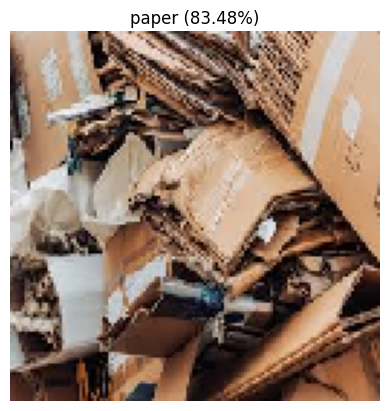

In [144]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.title(f"{pred_class} ({confidence:.2f}%)")
plt.axis('off')
plt.show()